## Importing libraries + reading data from csv format into pandas.DataFrame

In [35]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from pathlib import Path

DATA_PATH = Path("..") / "data" / "raw"

df_air_reserve = pd.read_csv(DATA_PATH / "air_reserve.csv")
df_air_store_info = pd.read_csv(DATA_PATH / "air_store_info.csv")
df_air_visit_data = pd.read_csv(DATA_PATH / "air_visit_data.csv")
df_date_info = pd.read_csv(DATA_PATH / "date_info.csv")
df_hpg_reserve = pd.read_csv(DATA_PATH / "hpg_reserve.csv")
df_hpg_store_info = pd.read_csv(DATA_PATH / "hpg_store_info.csv")
df_store_id_relation = pd.read_csv(DATA_PATH / "store_id_relation.csv")

In [37]:
data_frames = [
        df_air_reserve, df_air_store_info, df_air_visit_data, df_date_info,
        df_hpg_reserve, df_hpg_store_info, df_store_id_relation
    ]

data_frames_names = [
    "air_reserve", "air_store_info", "air_visit_data", "date_info",
    "hpg_reserve", "hpg_store_info", "store_id_relation"
]

## Counting nan values and unique values in the dataframes

In [38]:
from restaurant_visitor_eda.dataset import count_unique_and_nans

In [39]:
for i, df in enumerate(data_frames):
    print(data_frames_names[i])
    #display(count_unique_and_nans(df))
    print(count_unique_and_nans(df))

air_reserve
                  nan percentage  unique
air_store_id                 0.0     314
visit_datetime               0.0    4975
reserve_datetime             0.0    7513
reserve_visitors             0.0      71
air_store_info
                nan percentage  unique
air_store_id               0.0     829
air_genre_name             0.0      14
air_area_name              0.0     103
latitude                   0.0     108
longitude                  0.0     108
air_visit_data
              nan percentage  unique
air_store_id             0.0     829
visit_date               0.0     478
visitors                 0.0     204
date_info
               nan percentage  unique
calendar_date             0.0     517
day_of_week               0.0       7
holiday_flg               0.0       2
hpg_reserve
                  nan percentage  unique
hpg_store_id                 0.0   13325
visit_datetime               0.0    9847
reserve_datetime             0.0   11450
reserve_visitors             0.0 

## Conclusion: 

1) There are __no__ nan values in the data set, however, this does __not__ particularly mean that the data set is complete or consistent. The next points will look into my arguments in favour of this position

2) There $829$ unique restaurants in the air_store_info table, while only $314$ are covered in air_reserve. This means that we do not have any information about reserves made in $(829 - 314) = 515$ restaurants through air service.

3) The store_id_relation has only $150$ rows. Thus, we can join information from two services only for $150$ places, which is significantly smaller than the total number of the restaraunts in the area


## Target Value 

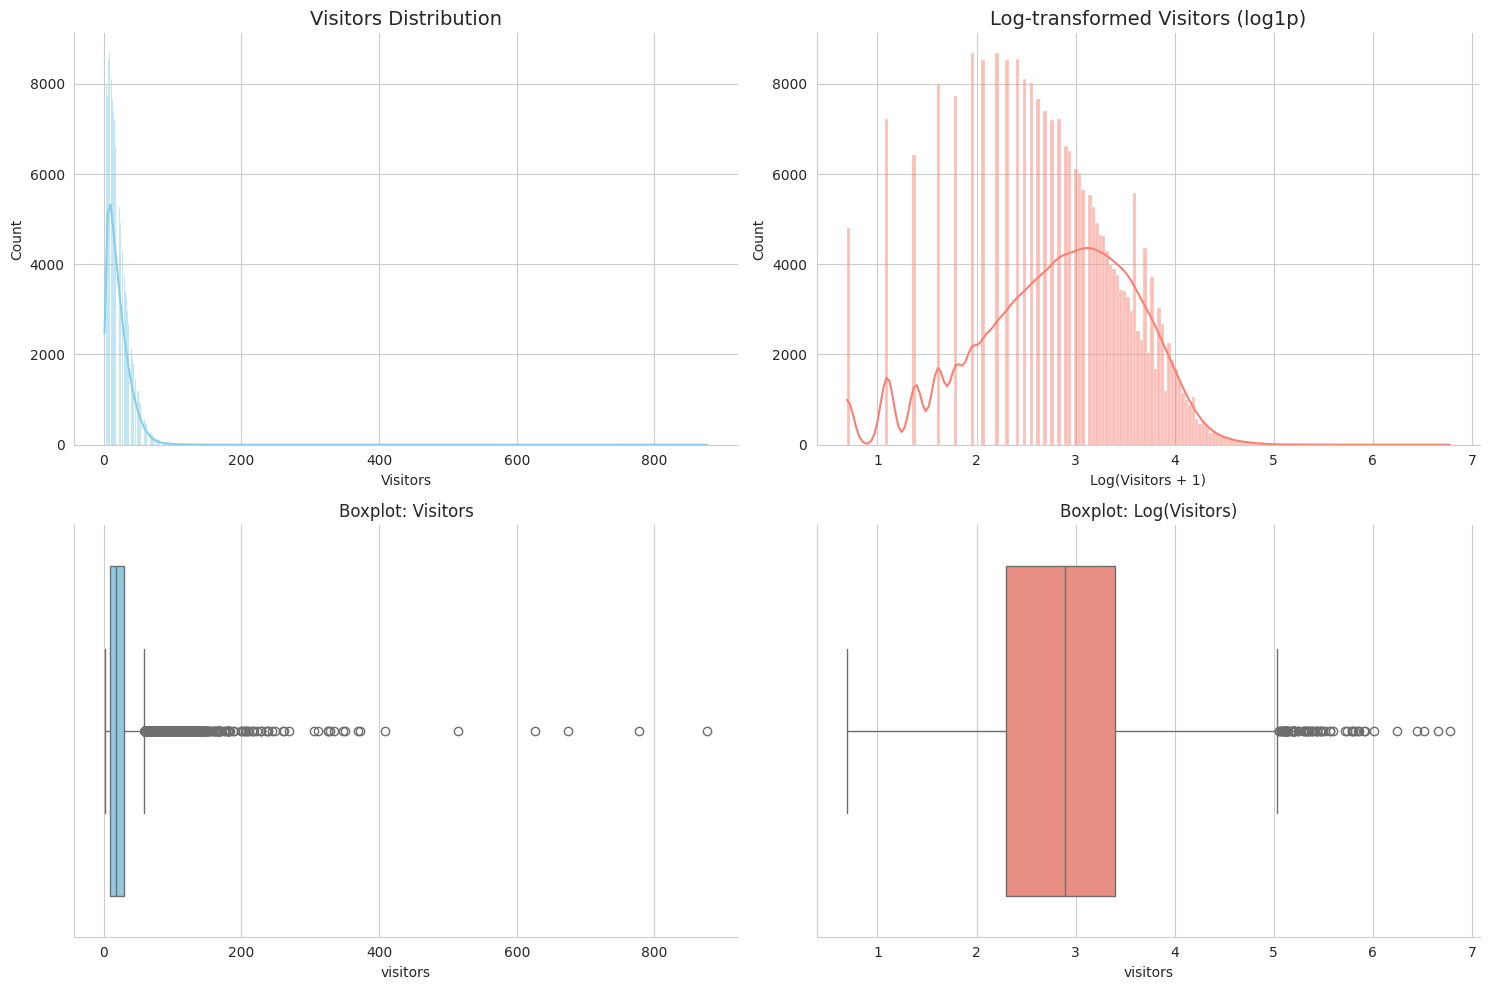

In [41]:
from restaurant_visitor_eda.plots import plot_target_distribution

plot_target_distribution(df_air_visit_data)

In [56]:
from restaurant_visitor_eda.dataset import get_stats

get_stats(pd.DataFrame(df_air_visit_data['visitors']))

,visitors
count,252108.000
mean,20.974
std,16.757
min,1.000
25%,9.000
50%,17.000
75%,29.000
95%,52.000
99%,73.000
max,877.000
